<a href="https://colab.research.google.com/github/2403a52029-lab/ML_Assignments/blob/main/ML_LAB_13_2403A2029.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install XGBoost (only needed in Colab)
!pip install xgboost

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

In [ ]:
df = pd.read_excel('/content/breast.xlsx')
display(df.head())

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
# Map 'M' to 1 and 'B' to 0 for the target variable
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# Define features (X) by dropping 'id' and 'diagnosis' columns
X = df.drop(columns=['id', 'diagnosis'])

# Define target (y) as the 'diagnosis' column
y = df['diagnosis']

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Gradient Boosting
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(X_train_scaled, y_train)

# XGBoost
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train_scaled, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:57:24] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
# Predictions
rf_pred = rf_model.predict(X_test_scaled)
gb_pred = gb_model.predict(X_test_scaled)
xgb_pred = xgb_model.predict(X_test_scaled)

# Probabilities for ROC-AUC
rf_prob = rf_model.predict_proba(X_test_scaled)[:, 1]
gb_prob = gb_model.predict_proba(X_test_scaled)[:, 1]
xgb_prob = xgb_model.predict_proba(X_test_scaled)[:, 1]

# Accuracy
rf_acc = accuracy_score(y_test, rf_pred)
gb_acc = accuracy_score(y_test, gb_pred)
xgb_acc = accuracy_score(y_test, xgb_pred)

# ROC-AUC
rf_auc = roc_auc_score(y_test, rf_prob)
gb_auc = roc_auc_score(y_test, gb_prob)
xgb_auc = roc_auc_score(y_test, xgb_prob)

# Print results
print("Model Performance:\n")

print(f"Random Forest -> Accuracy: {rf_acc:.4f}, ROC-AUC: {rf_auc:.4f}")
print(f"Gradient Boosting -> Accuracy: {gb_acc:.4f}, ROC-AUC: {gb_auc:.4f}")
print(f"XGBoost -> Accuracy: {xgb_acc:.4f}, ROC-AUC: {xgb_auc:.4f}")

Model Performance:

Random Forest -> Accuracy: 0.9649, ROC-AUC: 0.9953
Gradient Boosting -> Accuracy: 0.9561, ROC-AUC: 0.9951
XGBoost -> Accuracy: 0.9561, ROC-AUC: 0.9908


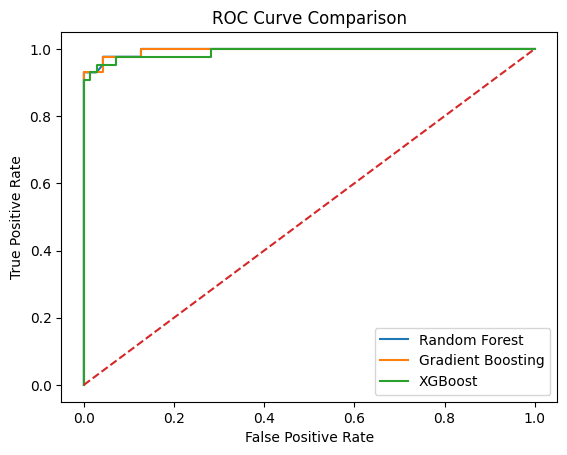

In [ ]:
# Compute ROC curves
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
gb_fpr, gb_tpr, _ = roc_curve(y_test, gb_prob)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_prob)

# Plot
plt.figure()

plt.plot(rf_fpr, rf_tpr, label="Random Forest")
plt.plot(gb_fpr, gb_tpr, label="Gradient Boosting")
plt.plot(xgb_fpr, xgb_tpr, label="XGBoost")

plt.plot([0, 1], [0, 1], linestyle='--')  # Diagonal line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()